# Feynmanator

## Feynman diagrams from a product of propagators

`feynmanator.py` draws a Feynman diagram from the factors of a term: `G(1,2)` is a Green's function (solid, no arrow; `G(1,1)` a closed loop), `Q(1,2)` a Coulomb line (wavy), `PI(1,2)` a polarisation loop (two arcs), `v(1)` and `w(2)` the external lines (arrows; the first one written enters at the top left, the second leaves at the right), `T(1)` a cross and `S(1,2)` a dashed line. The labels name the vertices, any letters or digits will do; nothing is drawn at a plain vertex and there are no labels.

There are no rules to derive here, only the picture, with the same exports as `goldstoninator.py` (SVG, PDF, TikZ).

In [1]:
import feynmanator as fd

First order: the exchange (Fock) and direct (Hartree, a tadpole) self-energy:

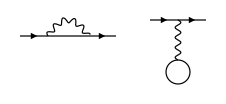

In [2]:
fd.grid(["v(1) G(1,2) w(2) Q(1,2)", "v(1) w(1) Q(1,2) G(2,2)"], ncols=2)

Second order: the direct term with a polarisation loop `PI(3,4)`, and the exchange term, whose two Coulomb lines must cross:

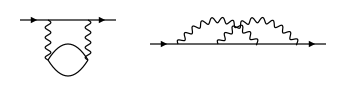

In [3]:
fd.grid(
    [
        "v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)",
        "v(1) G(1,2) G(2,3) G(3,4) w(4) Q(1,3) Q(2,4)",
    ],
    ncols=2,
)

An external field (`T`, a cross) acting directly on the valence line, through the Coulomb interaction, and through a screened interaction. A Coulomb line may end at the cross: its ends need not be fermion vertices.

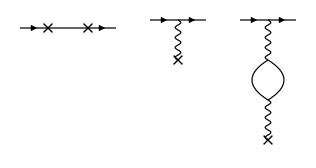

In [4]:
fd.grid(
    [
        "v(1) G(1,2) w(2) T(1) T(2)",
        "v(1) w(1) Q(1,2) T(2)",
        "v(1) w(1) Q(1,2) PI(2,3) Q(3,4) T(4)",
    ],
    ncols=3,
)

Chains of bubbles (RPA screening of the Coulomb line):

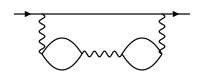

In [5]:
fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,5) PI(5,6) Q(6,2)")

A closed loop of `G` lines is drawn counterclockwise in the direction of propagation (`G(a,b)` runs from b to a), so writing the loop the other way round mirrors it. A field insertion `t(i)` on the valence line, and on the upper or the lower line of the loop:

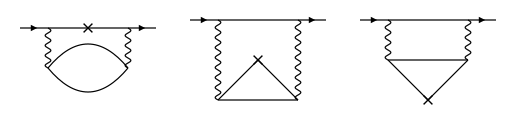

In [11]:
fd.grid(
    [
        "v(1) G(1,i) t(i) G(i,2) w(2) Q(1,3) PI(3,6) Q(6,2)",
        "v(1) G(1,2) w(2) Q(1,3) G(3,i) t(i) G(i,6) G(6,3) Q(6,2)",
        "v(1) G(1,2) w(2) Q(1,3) G(3,6) G(6,i) t(i) G(i,3) Q(6,2)",
    ]
)

Any other name with two labels is a dashed line, with one label a marker; `styles=` changes them (lines `wavy`, `dashed`, `dotted`, `double`, `solid`; markers `x`, `dot`, `circle`, `square`). `styles={'G': 'double'}` draws dressed propagators:

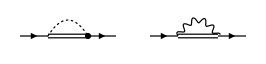

In [7]:
fd.grid(
    ["v(1) G(1,2) w(2) S(1,2) T(2)", "v(1) G(1,2) w(2) Q(1,2)"],
    ncols=2,
    styles={"S": "dotted", "T": "dot", "G": "double"},
)

The vertices sit on a small grid, with the incoming vertex leftmost, the outgoing one rightmost and the fermion line straight between them; `straight=False` frees it (`layout(cols=, rows=)` sets the grid by hand):

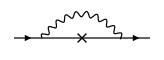

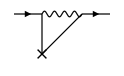

In [8]:
term = "v(1) G(1,2) G(2,3) w(3) Q(1,3) T(2)"
display(fd.diagram(term), fd.diagram(term, straight=False))

Export: `tikz()` gives the TikZ source (a document that `\input`s it needs `\usetikzlibrary{decorations.pathmorphing}` for the wavy lines); `save('fig.svg' / 'fig.pdf' / 'fig.tikz' / 'fig.tex')` writes a file, for grids too.

In [9]:
d = fd.diagram("v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)")
print(d.tikz())

% v(1) G(1,2) w(2) Q(1,3) PI(3,4) Q(4,2)
\begin{tikzpicture}[x=1cm,y=1cm,line width=0.85pt]
\draw (0,1) -- (1,1);
\draw[decorate,decoration={snake,amplitude=0.7mm,segment length=2.5mm}] (0,0) -- (0,1);
\draw[decorate,decoration={snake,amplitude=0.7mm,segment length=2.5mm}] (1,0) -- (1,1);
\draw (-0.7,1) -- (0,1);
\draw (1,1) -- (1.7,1);
\draw (0,0) .. controls (0.33,-0.53) and (0.67,-0.53) .. (1,0);
\draw (0,0) .. controls (0.33,0.53) and (0.67,0.53) .. (1,0);
\fill (-0.27,1) -- (-0.43,1.08) -- (-0.43,0.92) -- cycle;
\fill (1.43,1) -- (1.27,1.08) -- (1.27,0.92) -- cycle;
\end{tikzpicture}
